In [3]:
import time 
import platform 
import warnings 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

import qiskit 
import qiskit_aer 
from qiskit import QuantumCircuit, transpile 
from qiskit_aer import AerSimulator

In [4]:
print("Python:", platform.python_version()) 
print("Qiskit:", qiskit.__version__) 
print("Qiskit Aer:", qiskit_aer.__version__)

Python: 3.11.9
Qiskit: 2.4.2
Qiskit Aer: 0.17.2


## Why statevector simulation becomes expensive


A general \(n\)-qubit state is

$$
|\psi\rangle = \sum_{x \in \{0,1\}^n} \alpha_x |x\rangle .
$$

There are \(2^n\) amplitudes.

If each amplitude is stored as a double-precision complex number, that is roughly 16 bytes per amplitude.

So the memory cost is approximately

$$
16 \times 2^n \text{ bytes}.
$$

This ignores overhead, so the real memory use can be larger.

In [3]:
def estimate_statevector_memory_gb(n_qubits, bytes_per_complex=16):
    """
    Approximate memory needed to store a full statevector
    using complex128 amplitudes.
    """
    bytes_needed = (2 ** n_qubits) * bytes_per_complex
    return bytes_needed / (1024 ** 3)


for n in [10, 20, 25, 30, 35, 40]:
    print(f"{n:2d} qubits: {estimate_statevector_memory_gb(n):10.3f} GB")

10 qubits:      0.000 GB
20 qubits:      0.016 GB
25 qubits:      0.500 GB
30 qubits:     16.000 GB
35 qubits:    512.000 GB
40 qubits:  16384.000 GB


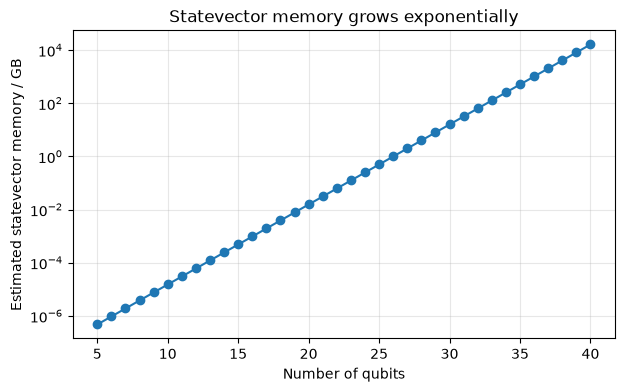

In [4]:
n_values_for_memory = np.arange(5, 41)
memory_gb = [estimate_statevector_memory_gb(n) for n in n_values_for_memory]

plt.figure(figsize=(7, 4))
plt.plot(n_values_for_memory, memory_gb, marker="o")
plt.yscale("log")
plt.xlabel("Number of qubits")
plt.ylabel("Estimated statevector memory / GB")
plt.title("Statevector memory grows exponentially")
plt.grid(True, which="both", alpha=0.3)
plt.show()

## 2. A low-entanglement 1D circuit

We now build a shallow 1D circuit.

The circuit has:

- single-qubit rotations,
- nearest-neighbour two-qubit gates,
- small circuit depth.

This is the kind of circuit where an MPS representation can remain compact.

The important point is that we increase the number of qubits while keeping the entangling depth small.

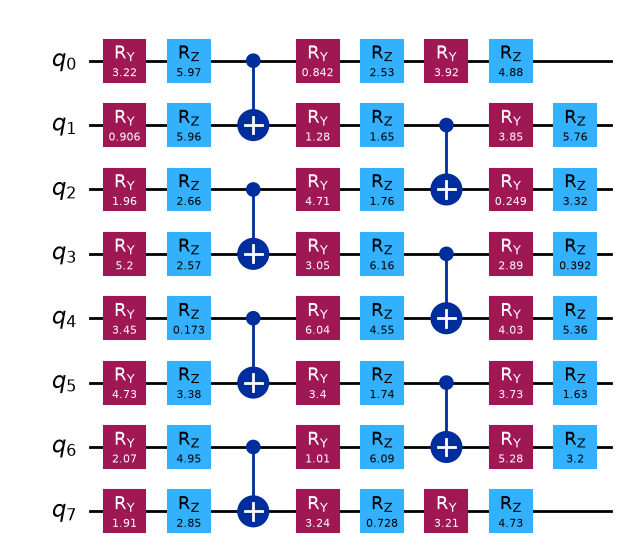

In [5]:
def low_entanglement_1d_circuit(n_qubits, depth=2, seed=0):
    """
    Build a shallow nearest-neighbour 1D circuit; whose entanglement is limited by shallow local structure.
    """
    rng = np.random.default_rng(seed)

    qc = QuantumCircuit(n_qubits)

    # Initial product-state layer
    for q in range(n_qubits):
        qc.ry(float(rng.uniform(0, 2 * np.pi)), q)
        qc.rz(float(rng.uniform(0, 2 * np.pi)), q)

    # Shallow brickwork of nearest-neighbour entangling gates
    for layer in range(depth):
        offset = layer % 2

        for q in range(offset, n_qubits - 1, 2):
            qc.cx(q, q + 1)

        # Local rotations after each entangling layer
        for q in range(n_qubits):
            qc.ry(float(rng.uniform(0, 2 * np.pi)), q)
            qc.rz(float(rng.uniform(0, 2 * np.pi)), q)

    return qc


qc_small = low_entanglement_1d_circuit(n_qubits=8, depth=2, seed=1)
qc_small.draw("mpl")

In [9]:
def add_measurements(qc):
    measured = qc.copy()
    measured.measure_all()
    return measured


def run_simulation(method, n_qubits, depth, shots=200, seed=1234):
    qc = low_entanglement_1d_circuit(
        n_qubits=n_qubits,
        depth=depth,
        seed=seed + n_qubits,
    )

    qc_measured = add_measurements(qc)

    backend = AerSimulator(
        method=method,
        seed_simulator=seed,
    )

    tqc = transpile(qc_measured, backend, optimization_level=0)

    start = time.perf_counter()
    result = backend.run(tqc, shots=shots).result()
    elapsed = time.perf_counter() - start

    counts = result.get_counts(0)

    return {
        "method": method,
        "n_qubits": n_qubits,
        "depth_parameter": depth,
        "shots": shots,
        "time_sec": elapsed,
        "distinct_outcomes": len(counts),
        "status": "ok",
    }

In [10]:
N_VALUES = [8, 12, 16, 20, 24, 28, 32, 40, 50]
DEPTH = 3
SHOTS = 2000

# Safety limit for statevector simulation.
# Increase this if your machine can handle more.
STATEVECTOR_MEMORY_LIMIT_GB = 0.1

methods = ["statevector", "matrix_product_state"]

In [11]:
rows = []

for method in methods:
    for n in N_VALUES:
        estimated_mem_gb = estimate_statevector_memory_gb(n)

        if method == "statevector" and estimated_mem_gb > STATEVECTOR_MEMORY_LIMIT_GB:
            rows.append({
                "method": method,
                "n_qubits": n,
                "depth_parameter": DEPTH,
                "shots": SHOTS,
                "time_sec": np.nan,
                "distinct_outcomes": np.nan,
                "estimated_statevector_memory_gb": estimated_mem_gb,
                "status": "skipped: estimated statevector memory too large",
            })
            continue

        try:
            out = run_simulation(
                method=method,
                n_qubits=n,
                depth=DEPTH,
                shots=SHOTS,
                seed=2026,
            )
            out["estimated_statevector_memory_gb"] = estimated_mem_gb
            rows.append(out)

        except Exception as exc:
            rows.append({
                "method": method,
                "n_qubits": n,
                "depth_parameter": DEPTH,
                "shots": SHOTS,
                "time_sec": np.nan,
                "distinct_outcomes": np.nan,
                "estimated_statevector_memory_gb": estimated_mem_gb,
                "status": f"failed: {type(exc).__name__}: {exc}",
            })

df = pd.DataFrame(rows)
df

NameError: name 'estimate_statevector_memory_gb' is not defined

In [7]:
ok_df = df[df["status"] == "ok"].copy()

plt.figure(figsize=(7, 4))

for method in ok_df["method"].unique():
    sub = ok_df[ok_df["method"] == method]
    plt.plot(
        sub["n_qubits"],
        sub["time_sec"],
        marker="o",
        label=method,
    )

plt.xlabel("Number of qubits")
plt.ylabel("Simulation time / seconds")
plt.title(f"Low-entanglement 1D circuit, depth={DEPTH}")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

NameError: name 'df' is not defined

In [11]:
def get_mps_from_circuit(qc, seed=1234):
    """
    Run an unmeasured circuit using the MPS simulator and save the internal MPS.
    """
    qc_mps = qc.copy()
    qc_mps.save_matrix_product_state(label="mps")

    backend = AerSimulator(
        method="matrix_product_state",
        seed_simulator=seed,
    )

    tqc = transpile(qc_mps, backend, optimization_level=0)
    result = backend.run(tqc).result()

    return result.data(0)["mps"]


def bond_dimensions_from_mps(mps):
    """
    Extract bond dimensions from the MPS data returned by Qiskit Aer.

    Aer usually returns:
        (mps_tensors, singular_value_vectors)

    The singular value vectors live on the bonds.
    Their lengths are the bond dimensions.
    """
    if not isinstance(mps, tuple) or len(mps) != 2:
        raise TypeError(
            "Unexpected MPS format. Print the object with `print(mps)` to inspect it."
        )

    _, singular_values = mps

    bond_dims = []
    for s in singular_values:
        bond_dims.append(len(np.asarray(s)))

    return bond_dims

In [12]:
def scrambling_circuit(n_qubits, depth=3, seed=0):
    """
    Build a more scrambling circuit using random two-qubit pairings.

    This is not an area-law-friendly 1D circuit.
    It is included only as a contrast.
    """
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(n_qubits)

    for q in range(n_qubits):
        qc.ry(float(rng.uniform(0, 2 * np.pi)), q)
        qc.rz(float(rng.uniform(0, 2 * np.pi)), q)

    for layer in range(depth):
        perm = rng.permutation(n_qubits)

        for i in range(0, n_qubits - 1, 2):
            a = int(perm[i])
            b = int(perm[i + 1])
            qc.cx(a, b)

        for q in range(n_qubits):
            qc.ry(float(rng.uniform(0, 2 * np.pi)), q)
            qc.rz(float(rng.uniform(0, 2 * np.pi)), q)

    return qc


N_SCRAMBLE = 16
SCRAMBLE_DEPTH_VALUES = [1, 2, 3, 4, 5,]

scramble_rows = []

for depth in SCRAMBLE_DEPTH_VALUES:
    try:
        qc = scrambling_circuit(
            n_qubits=N_SCRAMBLE,
            depth=depth,
            seed=200 + depth,
        )

        start = time.perf_counter()
        mps = get_mps_from_circuit(qc)
        elapsed = time.perf_counter() - start

        bond_dims = bond_dimensions_from_mps(mps)

        scramble_rows.append({
            "n_qubits": N_SCRAMBLE,
            "depth_parameter": depth,
            "max_bond_dimension": max(bond_dims),
            "mean_bond_dimension": float(np.mean(bond_dims)),
            "mps_save_time_sec": elapsed,
            "status": "ok",
        })

    except Exception as exc:
        scramble_rows.append({
            "n_qubits": N_SCRAMBLE,
            "depth_parameter": depth,
            "max_bond_dimension": np.nan,
            "mean_bond_dimension": np.nan,
            "mps_save_time_sec": np.nan,
            "status": f"failed: {type(exc).__name__}: {exc}",
        })

scramble_df = pd.DataFrame(scramble_rows)
scramble_df

,n_qubits,depth_parameter,max_bond_dimension,mean_bond_dimension,mps_save_time_sec,status
0,16,1,32,6.733333,0.201917,ok
1,16,2,32,12.733333,0.135980,ok
2,16,3,128,38.133333,0.360558,ok
3,16,4,128,42.400000,1.743575,ok
4,16,5,256,50.933333,10.823419,ok


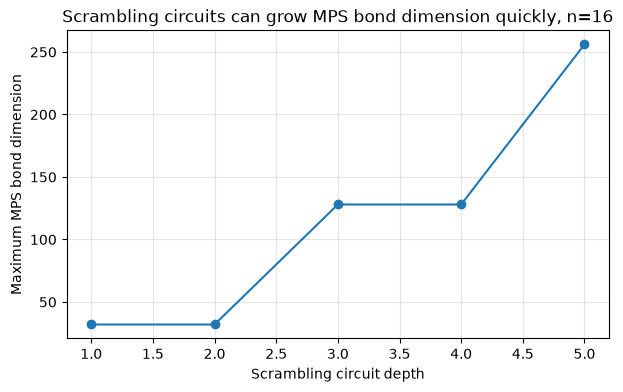

In [13]:
ok_scramble_df = scramble_df[scramble_df["status"] == "ok"]

plt.figure(figsize=(7, 4))
plt.plot(
    ok_scramble_df["depth_parameter"],
    ok_scramble_df["max_bond_dimension"],
    marker="o",
)

plt.xlabel("Scrambling circuit depth")
plt.ylabel("Maximum MPS bond dimension")
plt.title(f"Scrambling circuits can grow MPS bond dimension quickly, n={N_SCRAMBLE}")
plt.grid(True, alpha=0.3)
plt.show()

## Takeaway

The statevector simulator stores the full amplitude vector.

Its cost grows with


$2^n$

The MPS simulator stores a tensor network.

Its cost depends strongly on the bond dimensions, which are related to entanglement across cuts.

So:

- low-entanglement $1d$ states can be MPS-friendly,
- shallow local circuits can be MPS-friendly,
- highly entangled or scrambling circuits can become MPS-hard,
- MPS is not a universal shortcut.

The practical message is:

> Classical simulability depends not only on the number of qubits, but also on the structure of the quantum state and circuit.